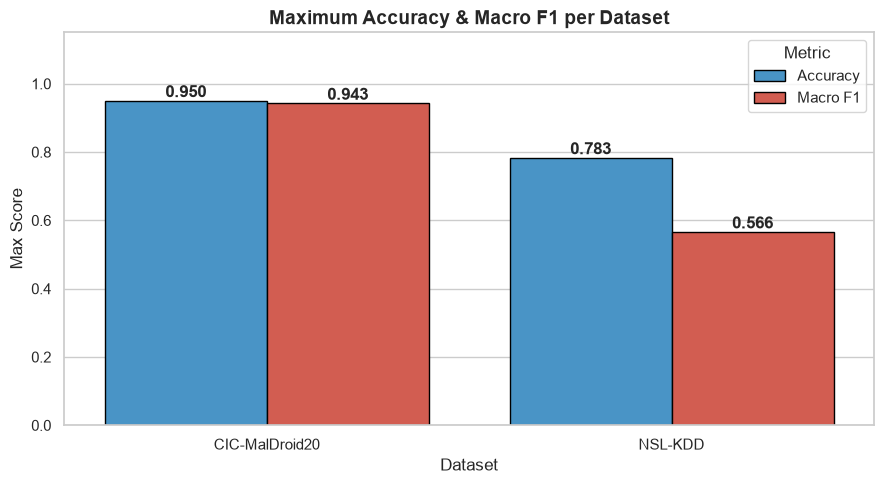

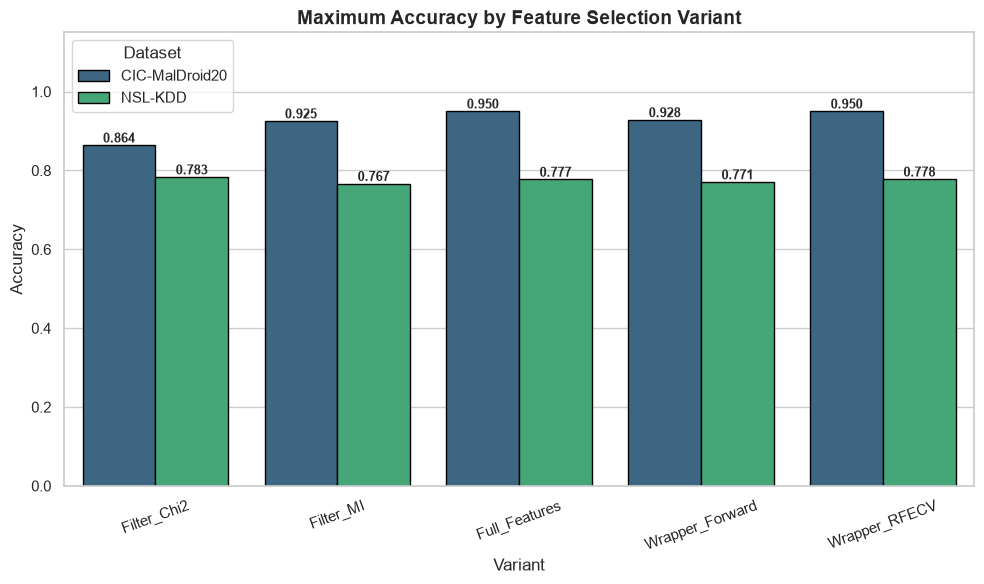

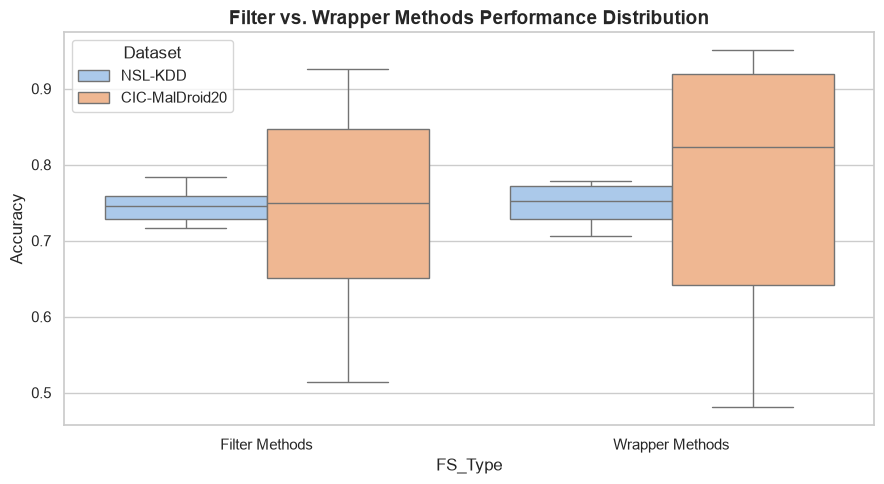

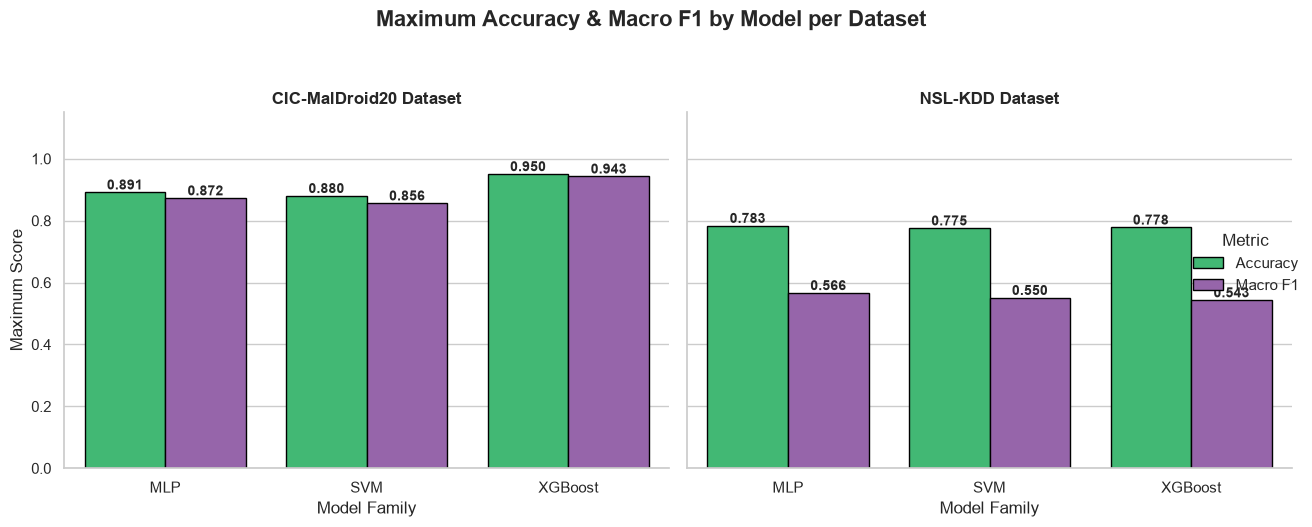

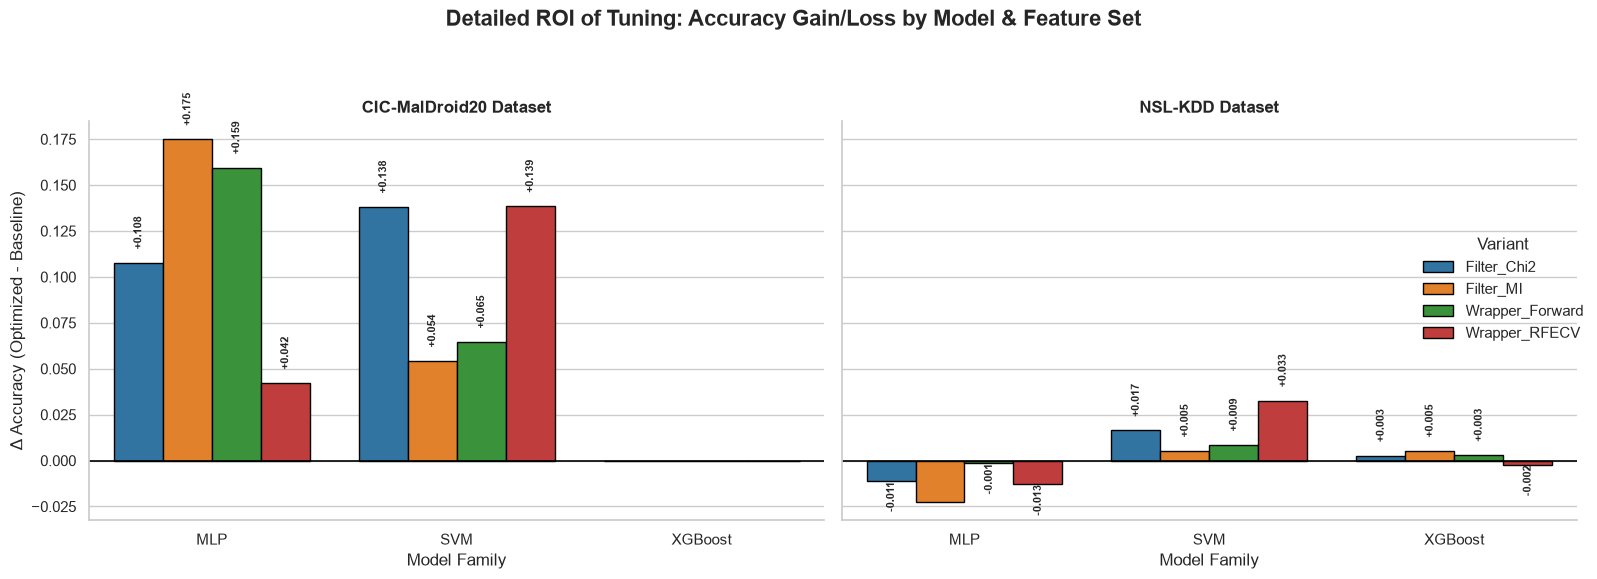

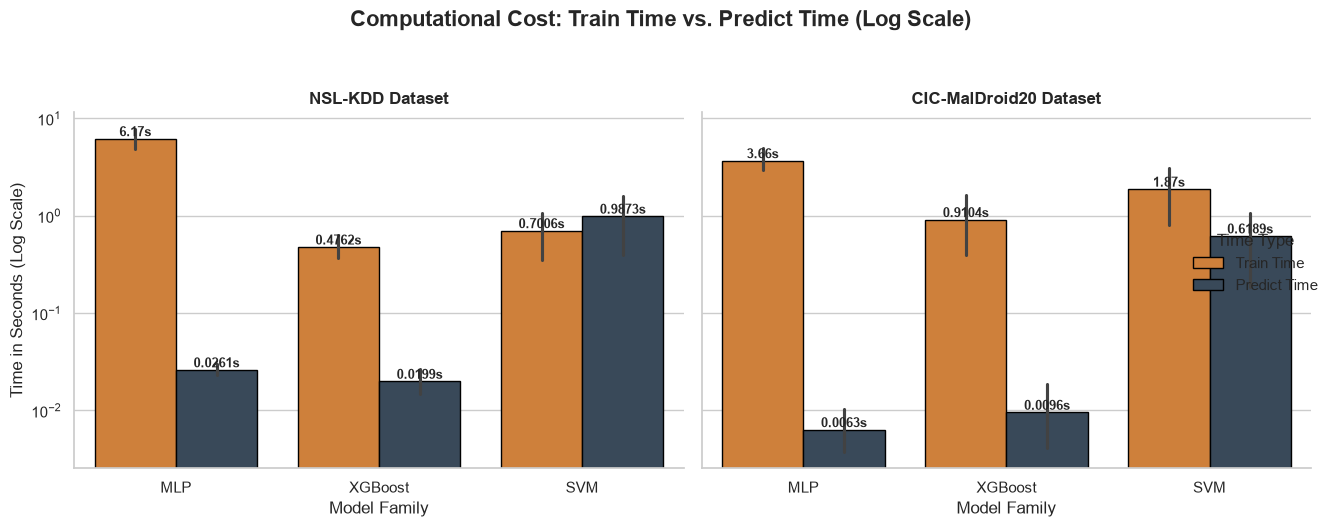

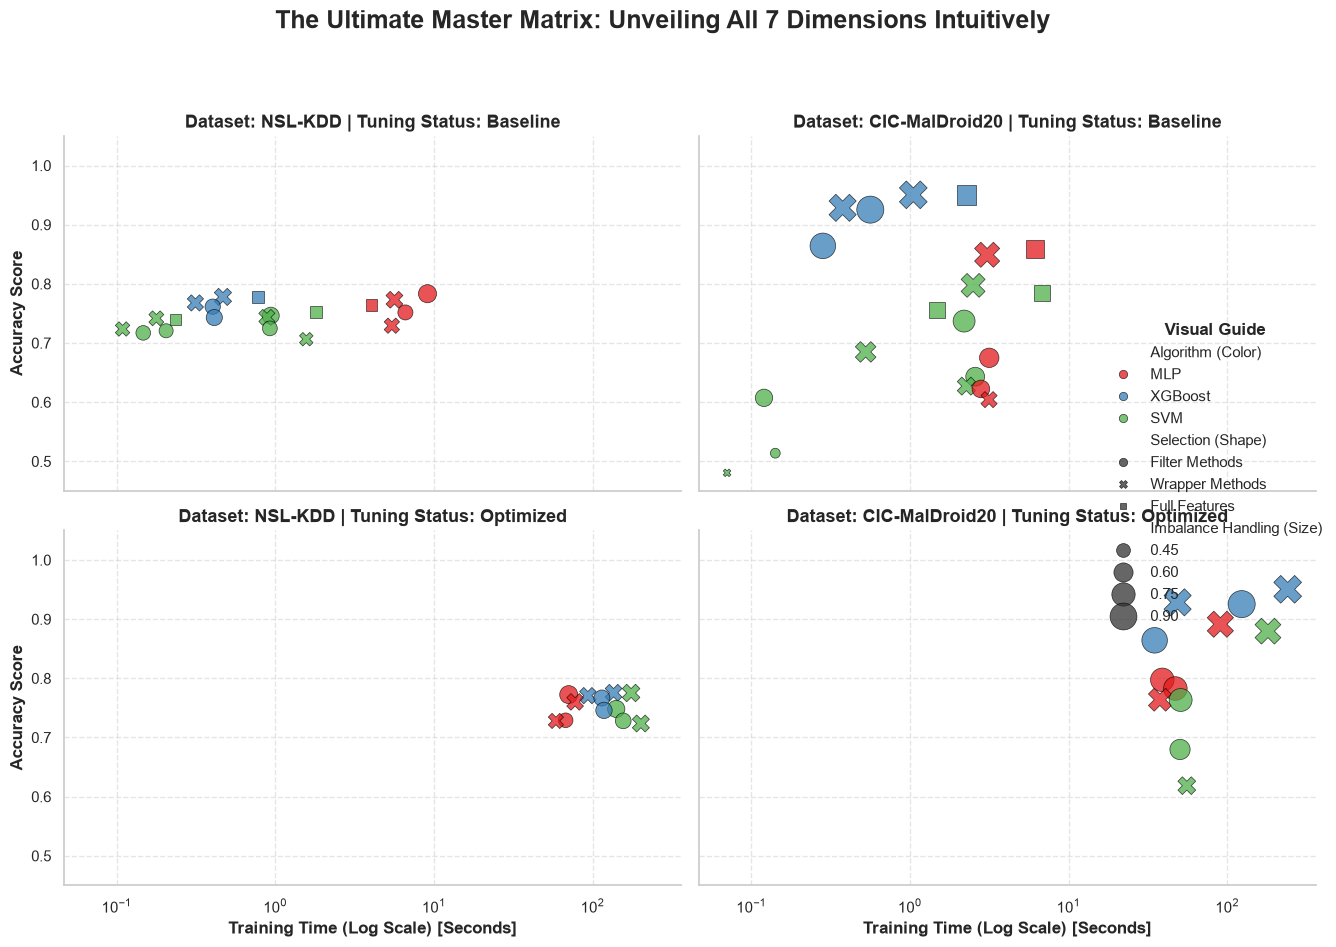

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


try:
    df_nsl = pd.read_csv('NSL_KDD_Resultsqq.csv')
    df_cic = pd.read_csv('CIC_MalDroid_Resultsqq.csv')
    df_all = pd.concat([df_nsl, df_cic], ignore_index=True)
except FileNotFoundError:
    exit()

def categorize_fs(variant):
    if 'Filter' in variant: return 'Filter Methods'
    elif 'Wrapper' in variant: return 'Wrapper Methods'
    return 'Full Features'

df_all['FS_Type'] = df_all['Variant'].apply(categorize_fs)

sns.set_theme(style="whitegrid")


plt.figure(figsize=(9, 5))
best_ds = df_all.groupby('Dataset')[['Accuracy', 'Macro F1']].max().reset_index()
best_ds_melted = best_ds.melt(id_vars='Dataset', var_name='Metric', value_name='Max Score')

ax = sns.barplot(data=best_ds_melted, x='Dataset', y='Max Score', hue='Metric', palette=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('Maximum Accuracy & Macro F1 per Dataset', fontweight='bold', fontsize=14)
plt.ylim(0, 1.15)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
fs_impact = df_all.groupby(['Dataset', 'Variant'])['Accuracy'].max().reset_index()

ax = sns.barplot(data=fs_impact, x='Variant', y='Accuracy', hue='Dataset', palette='viridis', edgecolor='black')
plt.title('Maximum Accuracy by Feature Selection Variant', fontweight='bold', fontsize=14)
plt.xticks(rotation=20)
plt.ylim(0, 1.15)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
fs_only = df_all[df_all['FS_Type'] != 'Full Features']
ax = sns.boxplot(data=fs_only, x='FS_Type', y='Accuracy', hue='Dataset', palette='pastel')
plt.title('Filter vs. Wrapper Methods Performance Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# ===================================================================
# Plot 4: Maximum Accuracy & Macro F1 by Model per Dataset
# ===================================================================
best_models = df_all.groupby(['Dataset', 'Family'])[['Accuracy', 'Macro F1']].max().reset_index()
best_models_melted = best_models.melt(id_vars=['Dataset', 'Family'], value_vars=['Accuracy', 'Macro F1'], var_name='Metric', value_name='Max Score')

g = sns.catplot(data=best_models_melted, kind='bar', x='Family', y='Max Score', hue='Metric', col='Dataset', 
                palette=['#2ecc71', '#9b59b6'], edgecolor='black', height=5, aspect=1.2)
g.fig.suptitle('Maximum Accuracy & Macro F1 by Model per Dataset', fontweight='bold', fontsize=16, y=1.05)
g.set_axis_labels("Model Family", "Maximum Score")
g.set_titles("{col_name} Dataset", fontweight='bold')

for ax in g.axes.flat:
    ax.set_ylim(0, 1.15)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


pivot_df = df_all.pivot_table(index=['Dataset', 'Family', 'Variant'], columns='Status', values='Accuracy').reset_index()
pivot_df = pivot_df.dropna(subset=['Baseline', 'Optimized'])
pivot_df['Tuning_Gain'] = pivot_df['Optimized'] - pivot_df['Baseline']

g = sns.catplot(data=pivot_df, kind='bar', x='Family', y='Tuning_Gain', hue='Variant', col='Dataset', 
                palette='tab10', edgecolor='black', height=5.5, aspect=1.3)

g.fig.suptitle('Detailed ROI of Tuning: Accuracy Gain/Loss by Model & Feature Set', fontweight='bold', fontsize=16, y=1.05)
g.set_axis_labels("Model Family", "Δ Accuracy (Optimized - Baseline)")
g.set_titles("{col_name} Dataset", fontweight='bold')

for ax in g.axes.flat:
    ax.axhline(0, color='black', linewidth=1.2) 
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height != 0:
            y_pos = height + (0.005 if height > 0 else -0.015)
            ax.annotate(f"{height:+.3f}", (p.get_x() + p.get_width() / 2., y_pos),
                        ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=90,
                        xytext=(0, 3 if height > 0 else -3), textcoords='offset points')

plt.tight_layout()
plt.show()


df_baseline = df_all[df_all['Status'] == 'Baseline']
time_melted = df_baseline.melt(id_vars=['Dataset', 'Family'], value_vars=['Train Time', 'Predict Time'], var_name='Time Type', value_name='Seconds')

g = sns.catplot(data=time_melted, kind='bar', x='Family', y='Seconds', hue='Time Type', col='Dataset', 
                palette=['#e67e22', '#34495e'], edgecolor='black', height=5, aspect=1.2)
g.fig.suptitle('Computational Cost: Train Time vs. Predict Time (Log Scale)', fontweight='bold', fontsize=16, y=1.05)
g.set_axis_labels("Model Family", "Time in Seconds (Log Scale)")
g.set_titles("{col_name} Dataset", fontweight='bold')

for ax in g.axes.flat:
    ax.set_yscale('log')
    for p in ax.patches:
        height = p.get_height()
        if height > 0 and not np.isnan(height):
            label = f"{height:.4f}s" if height < 1 else f"{height:.2f}s"
            ax.annotate(label, (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

g_master = sns.relplot(
    data=df_all,
    x='Train Time', 
    y='Accuracy', 
    hue='Family',             
    style='FS_Type',          
    size='Macro F1',          
    col='Dataset',            
    row='Status',             
    palette='Set1',           
    sizes=(30, 400),          
    alpha=0.75,
    height=4.5, 
    aspect=1.3,
    kind='scatter',
    edgecolor='black',
    linewidth=0.5
)

g_master.fig.suptitle('The Ultimate Master Matrix: Unveiling All 7 Dimensions Intuitively', 
                      fontweight='bold', fontsize=18, y=1.05)
g_master.set_axis_labels('Training Time (Log Scale) [Seconds]', 'Accuracy Score', fontweight='bold')
g_master.set_titles("Dataset: {col_name} | Tuning Status: {row_name}", fontweight='bold', size=13)

for ax in g_master.axes.flat:
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0.45, 1.05) 

leg = g_master._legend
leg.set_title("Visual Guide", prop={'weight':'bold', 'size':12})
for t in leg.texts:
    if t.get_text() == 'Family':
        t.set_text('Algorithm (Color)')
    elif t.get_text() == 'FS_Type':
        t.set_text('Selection (Shape)')
    elif t.get_text() == 'Macro F1':
        t.set_text('Imbalance Handling (Size)')

plt.tight_layout()
plt.show()